# Task B — From R to Python: Translating Statistical Analysis
> **BAFAD Accelerated Research Track · Fall 2026**

This task bridges your STAT 270 R work with the Python data science ecosystem used in AI research.
You will reproduce three analyses from Assignment 1 — originally written in R using `dplyr` and `ggplot2` — in Python using `pandas` and `matplotlib`.

**Reference file:** `task_b_r_original.R` (in this folder) — contains the complete R code you are translating.

**Data:** `../data/flights.csv` and `../data/airports.csv`

**Submission:** Push your completed notebook to your fork of the starter repository and paste the repo URL into the Canvas assignment.

## Setup

Run this cell first.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

NAVY = '#021B3A'
BLUE = '#0EA5E9'
plt.rcParams.update({'figure.dpi': 100, 'axes.spines.top': False, 'axes.spines.right': False})

flights  = pd.read_csv('../data/flights.csv')
airports = pd.read_csv('../data/airports.csv')

print(f'flights:  {flights.shape[0]:,} rows × {flights.shape[1]} columns')
print(f'airports: {airports.shape[0]} rows × {airports.shape[1]} columns')
flights.head(3)

flights:  1,000 rows × 19 columns
airports: 35 rows × 8 columns


,year,month,day,dep_time,sched_dep_time,dep_delay,arr_time,sched_arr_time,arr_delay,carrier,flight,tailnum,origin,dest,air_time,distance,hour,minute,time_hour
0,2013,7,27,669,645,24,1083,1059,45,F9,4502,N772AA,LGA,MKE,254,2294,6,45,2013-07-27 06:00:00
1,2013,7,11,693,715,-22,1334,1356,-9,YV,8275,N414EF,LGA,MCO,401,3254,7,15,2013-07-11 07:00:00
2,2013,3,3,1466,1415,51,2071,2020,58,F9,6396,N348AE,JFK,PHX,365,3196,14,15,2013-03-03 14:00:00


---
## Question 2 — Frequency Tables and Proportions (10 pts)

### Part A (4 pts)
Compute the **number of flights** and the **proportion of all flights** operated by each carrier.
Display the result sorted from most to least flights.

**R equivalent:**
```r
flights |> count(carrier, sort = TRUE) |> mutate(prop = n / sum(n))
```

*Python hints:*
- `flights['carrier'].value_counts()` gives counts sorted descending.
- Divide by `len(flights)` to get proportions.
- Build a `pd.DataFrame` with columns `carrier`, `n`, `prop`.

In [4]:
# YOUR CODE HERE
carrier_counts = pd.DataFrame({
    'carrier': flights['carrier'].value_counts().index,
    'n': flights['carrier'].value_counts().values,
    'prop': flights['carrier'].value_counts().values / len(flights)})

carrier_counts

,carrier,n,prop
0,F9,74,0.074
1,B6,72,0.072
2,US,71,0.071
3,UA,68,0.068
4,DL,67,0.067
5,MQ,66,0.066
6,VX,64,0.064
7,9E,63,0.063
8,YV,61,0.061
9,EV,61,0.061


**Answer** — Which carrier operated the most flights? What was its approximate share?

>F9 operated the most flights with 74 flights, which was approximately 7.4% of all flights.

### Part B (6 pts)
Compute the **proportion of flights that arrived late** (`arr_delay > 0`) for each carrier,
sorted from highest to lowest late-arrival rate.

**R equivalent:**
```r
flights |> group_by(carrier) |>
  summarise(late_rate = mean(arr_delay > 0, na.rm = TRUE)) |>
  arrange(desc(late_rate))
```

*Python hints:*
- `(flights['arr_delay'] > 0)` produces a boolean Series; take `.mean()` per group.
- Use `groupby('carrier').apply(...)` or `groupby('carrier')['arr_delay'].agg(...)`.

In [3]:
# YOUR CODE HERE
late_arrivals = (flights['arr_delay'] > 0).groupby(flights['carrier']).mean().sort_values(ascending=False)

late_arrivals


carrier
AS    0.735849
UA    0.705882
YV    0.704918
US    0.704225
HA    0.689655
VX    0.687500
DL    0.686567
AA    0.672414
9E    0.650794
EV    0.639344
MQ    0.636364
OO    0.634615
FL    0.603774
B6    0.597222
F9    0.554054
WN    0.525424
Name: arr_delay, dtype: float64



AS had the worst on-time arrival record, with approximately 73.6% of its flights arriving late.

---
## Question 3 — Histogram, Density, and Shape (15 pts)

### Part A (7 pts)
Create a **density histogram** of `dep_delay`, restricted to flights where `dep_delay` is between −60 and 180 minutes.
Overlay a kernel density estimate (KDE) curve.

- Use `NAVY` (`'#021B3A'`) for the histogram bars.
- Use `BLUE` (`'#0EA5E9'`) for the KDE line.
- Apply `plt.style.use('seaborn-v0_8-whitegrid')` or `plt.rcParams` for a clean background.

**R equivalent:**
```r
flights_filtered |> ggplot(aes(x = dep_delay)) +
  geom_histogram(aes(y = after_stat(density)), fill='#021B3A') +
  geom_density(colour='#0EA5E9') + theme_bw()
```

*Python hints:*
- Filter: `df_filtered = flights[(flights['dep_delay'] >= -60) & (flights['dep_delay'] <= 180)]`
- `ax.hist(..., density=True)` gives a density-normalised histogram.
- `from scipy.stats import gaussian_kde` or `df_filtered['dep_delay'].plot.kde(ax=ax)` for the curve.

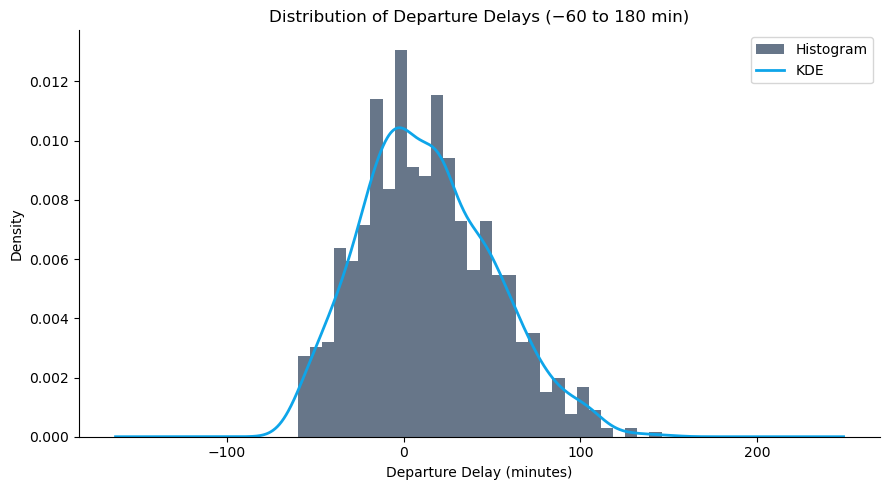

In [6]:
from scipy.stats import gaussian_kde

df_filtered = flights[(flights['dep_delay'] >= -60) & (flights['dep_delay'] <= 180)].copy()

fig, ax = plt.subplots(figsize=(9, 5))

# YOUR CODE HERE 
ax.hist(df_filtered['dep_delay'].dropna(), bins=30, density=True,
        color=NAVY, alpha=0.6, label='Histogram')

df_filtered['dep_delay'].dropna().plot.kde(
    ax=ax, color=BLUE, linewidth=2, label='KDE'
)

ax.legend()

ax.set_xlabel('Departure Delay (minutes)')
ax.set_ylabel('Density')
ax.set_title('Distribution of Departure Delays (−60 to 180 min)')
plt.tight_layout()
plt.show()

### Part B (8 pts)
Compute and report the **median** and **IQR** of `dep_delay` (same filtered range), then describe the distribution in complete sentences addressing: shape, modality, centre, and spread.

In [7]:
# YOUR CODE HERE
median_delay = median_delay = df_filtered['dep_delay'].median()
iqr_delay = df_filtered['dep_delay'].quantile(0.75) - df_filtered['dep_delay'].quantile(0.25)
print(f'Median departure delay: {median_delay:.1f} min')
print(f'IQR of departure delay: {iqr_delay:.1f} min')

Median departure delay: 11.0 min
IQR of departure delay: 53.8 min


**Answer** — Shape, modality, centre, spread:

The distribution is unimodal and slightly right-skewed, with one main peak. The median departure delay is 11.0 minutes, which represents the center of the distribution. The IQR is 53.8 minutes, showing that the middle 50% of departure delays are spread across about 53.8 minutes.

---
## Question 4 — Grouped Summaries by Origin Airport (15 pts)

### Part A (7 pts)
For each of the three origin airports (EWR, JFK, LGA), compute the **mean, median, standard deviation, and IQR** of `arr_delay`.
Display the results as a summary table.

**R equivalent:**
```r
flights |> group_by(origin) |>
  summarise(mean_arr=mean(arr_delay,na.rm=T), median_arr=median(...), sd_arr=sd(...), iqr_arr=IQR(...))
```

*Python hints:*
- Use `flights.groupby('origin')['arr_delay'].agg(['mean','median','std'])` and add IQR via `lambda`.
- For IQR: `from scipy.stats import iqr` or `lambda x: x.quantile(0.75) - x.quantile(0.25)`.

In [8]:
from scipy.stats import iqr as scipy_iqr

# YOUR CODE HERE
origin_summary = origin_summary = flights.groupby('origin')['arr_delay'].agg(
    mean='mean',
    median='median',
    std='std',
    IQR=lambda x: x.quantile(0.75) - x.quantile(0.25)
)

origin_summary

,mean,median,std,IQR
origin,,,,
EWR,16.344411,15.0,43.273994,56.0
JFK,20.057637,19.0,43.273791,58.0
LGA,15.096273,15.0,42.417081,57.5


### Part B (8 pts)
Based on your table, answer in complete sentences:
1. Which airport has the **highest mean** arrival delay? Lowest?
2. For each airport, is the mean **higher or lower** than the median? What does this imply about the shape of each delay distribution?
3. Which airport shows the **greatest spread** (use SD to support your answer)?

**Answer:**

JFK has the highest mean arrival delay at about 20.06 minutes, while LGA has the lowest at about 15.10 minutes. The mean is higher than the median for EWR, JFK, and LGA, which suggests that all three delay distributions are slightly right-skewed. EWR has a mean of 16.34 compared to a median of 15, JFK has a mean of 20.06 compared to a median of 19, and LGA has a mean of 15.10 compared to a median of 15. EWR shows the greatest spread with a standard deviation of about 43.27 minutes, although JFK is extremely close.

---
## Reflection (not graded — but read before Task C)

Take 5 minutes to jot down:
- What was the hardest part of translating R to Python?
- What Python feature did you find most useful or surprising?
- How do `pandas` and `dplyr` differ in their approach to grouped operations?

You will expand on this in `task-c/reflection.md`.